# Thống kê mô tả chất lượng rượu

## 1. Định nghĩa
+ **Mô tả**: Bộ dữ liệu Wine Quality (Chất lượng rượu vang) bao gồm các thông tin của nhiều mẫu rượu vang, được sử dụng để phân tích và đánh giá chất lượng rượu dựa trên các chỉ số đo lường. Mỗi mẫu rượu trong bộ dữ liệu tương ứng với một tập hợp các đặc trưng trong quá trình kiểm định chất lượng.
+ **Dữ liệu vào**:
  + Fixed Acidity: độ axit cố định

  + Volatile Acidity: độ axit bay hơi

  + Citric Acid: hàm lượng axit citric

  + Residual Sugar: lượng đường còn lại sau quá trình lên men

  + Chlorides: hàm lượng muối (Cl⁻)

  + Free Sulfur Dioxide: lượng SO₂ tự do

  + Total Sulfur Dioxide: tổng lượng SO₂

  + Density: khối lượng riêng của rượu

  + pH: độ pH (mức độ axit/bazơ)

  + Sulphates: hàm lượng muối sunfat (SO₄²⁻)

  + Alcohol: nồng độ cồn (% thể tích)

  + Quality: điểm chất lượng rượu (thường từ 0–10)

## 2. Import các thư viện cần thiết

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## 3. Load dữ liệu

In [ ]:
data = pd.read_csv("/content/sample_data/winequality-red.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 4. Loại bỏ dữ liệu trùng lặp

In [ ]:
# Kiểm tra và loại bỏ dữ liệu trùng lặp
data_duplicate = data.drop_duplicates()

# Kiểm tra số lượng dòng trùng lặp
data.duplicated().sum()

# Kiểm tra kích thước sau khi loại bỏ trùng lặp
data_duplicate.shape

# Xoá một dòng cụ thể theo index
data.drop(labels=[1], axis=0)

# Xoá một cột cụ thể
data.drop(labels=['density'], axis=1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,3.57,0.71,10.2,5


## 5. Thay thế và thay đổi định dạng dữ liệu

In [ ]:
# Thay thế giá trị trong cột quality
data['quality_label'] = data['quality'].replace(
    [3, 4, 5, 6, 7, 8],
    ['very poor', 'poor', 'average', 'good', 'very good', 'excellent'])

# Điền giá trị thiếu cho cột alcohol bằng 0
data['alcohol'] = data['alcohol'].fillna(0)

# Chuyển kiểu dữ liệu alcohol sang float
data['alcohol_changed'] = data['alcohol'].astype(float)

## 6. Xử lý dữ liệu thiếu

In [ ]:
# Kiểm tra dữ liệu bị thiếu
print(data.isnull().sum())

# Điền giá trị bị thiếu bằng giá trị trung bình của các cột số
numeric_cols = data.select_dtypes(include=np.number).columns
data_filled = data.fillna(data[numeric_cols].mean())

# Loại bỏ các dòng có giá trị bị thiếu
data_dropped = data.dropna()
print(data_dropped.shape)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_label           0
alcohol_changed         0
dtype: int64
(1599, 14)


In [ ]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alcohol_changed
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,14.900000


## 7. Tính các giá trị

In [ ]:
# Tính giá trị trung bình (mean) của cột alcohol
data_mean = np.mean(data['alcohol'])
# Tính giá trị trung vị (Median) của cột alcohol
data_median = np.median(data['alcohol'])
# Tính giá trị mode (Giá trị xuất hiện nhiều nhất)
data_mode = stats.mode(data['alcohol'], keepdims=True)[0][0]
# Tính giá trị phương sai (Variance)
data_variance = np.var(data['alcohol'])
# Tính giá trị lệch chuẩn (Standard Deviation)
data_std = np.std(data['alcohol'])
# Tính giá trị nhỏ nhất (Minimum)
data_min = np.min(data['alcohol'])
# Tính giá trị lớn nhất (Maximum)
data_max = np.max(data['alcohol'])
# Tính khoảng giá trị (Range)
data_range = data_max - data_min
# Tính Percentile thứ 60 (giá trị tại vị trí 60%)
data_percentile_60 = np.percentile(data['alcohol'], 60)
# Tính phần tư thứ nhất (Q1)
data_quartile_1 = np.quantile(data['alcohol'], 0.25)
# Tính phần tư thứ ba (Q3)
data_quartile_3 = np.quantile(data['alcohol'], 0.75)
# Tính khoảng tứ phân vị (Interquartile Range - IQR)
data_IQR = stats.iqr(data['alcohol'])

In [ ]:
print(f"Mean: {data_mean}")
print(f"Median: {data_median}")
print(f"Mode: {data_mode}")
print(f"Variance: {data_variance}")
print(f"Standard Deviation: {data_std}")
print(f"Range: {data_range}")
print(f"60th Percentile: {data_percentile_60}")
print(f"1st Quartile (Q1): {data_quartile_1}")
print(f"3rd Quartile (Q3): {data_quartile_3}")
print(f"IQR (Q3 - Q1): {data_IQR}")

Mean: 10.422983114446529
Median: 10.2
Mode: 9.5
Variance: 1.1349371714888994
Standard Deviation: 1.0653343003437463
Range: 6.5
60th Percentile: 10.5
1st Quartile (Q1): 9.5
3rd Quartile (Q3): 11.1
IQR (Q3 - Q1): 1.5999999999999996


## 6. Trực quan hóa dữ liệu

### 6.1. Biểu đồ phân bố tần suất - Histogram

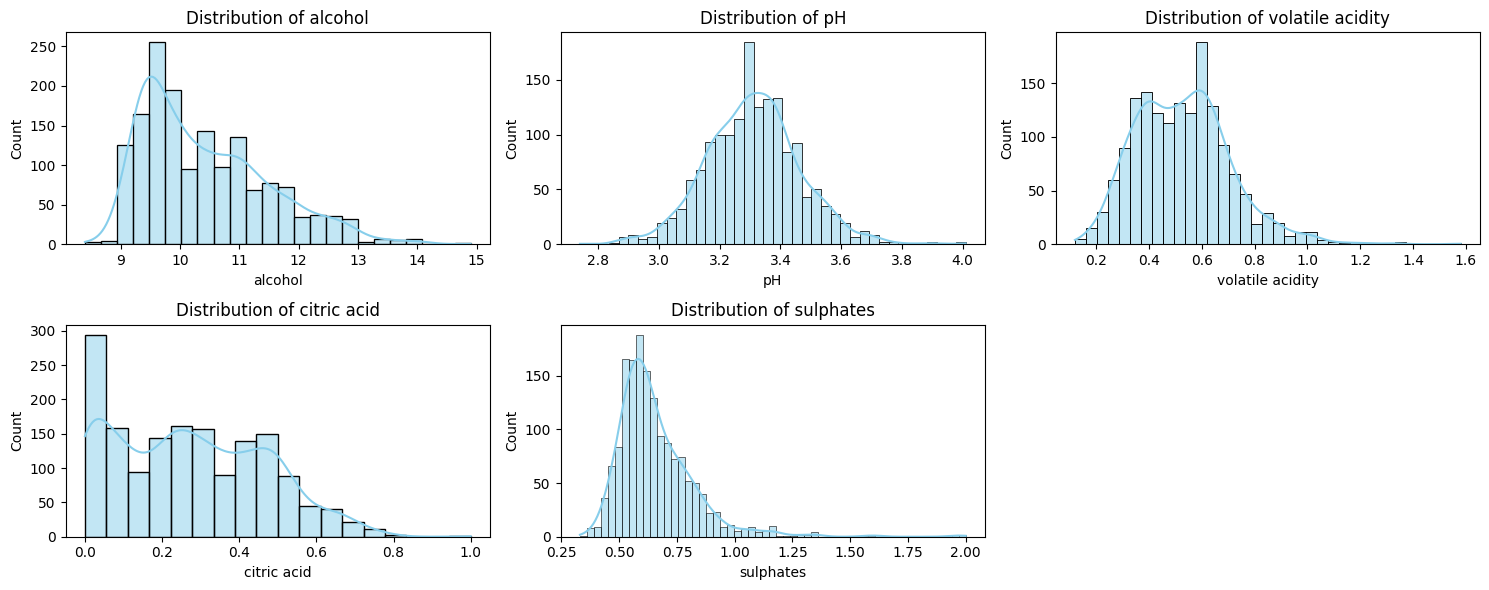

In [ ]:
cols = ['alcohol', 'pH', 'volatile acidity', 'citric acid', 'sulphates']

plt.figure(figsize=(15,6))
for i, col in enumerate(cols, 1):
    plt.subplot(2,3,i)
    sns.histplot(data[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 6.2. Biểu đồ hộp - Boxplot

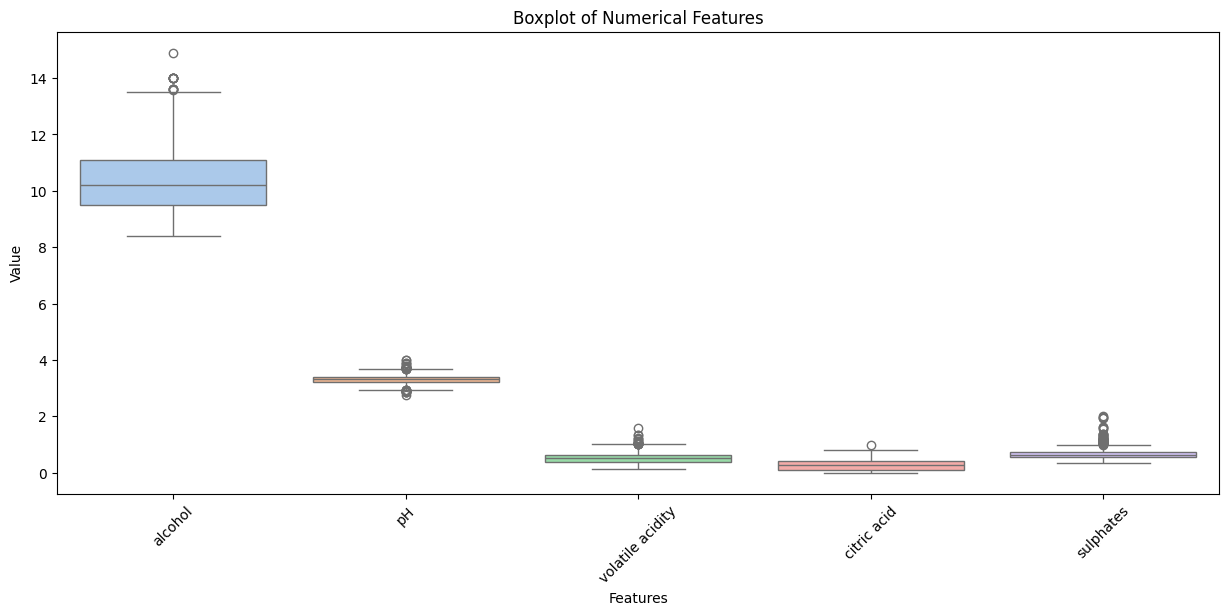

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(data=data[cols], palette="pastel")
plt.title("Boxplot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

### 6.3. Biểu đồ tương quan

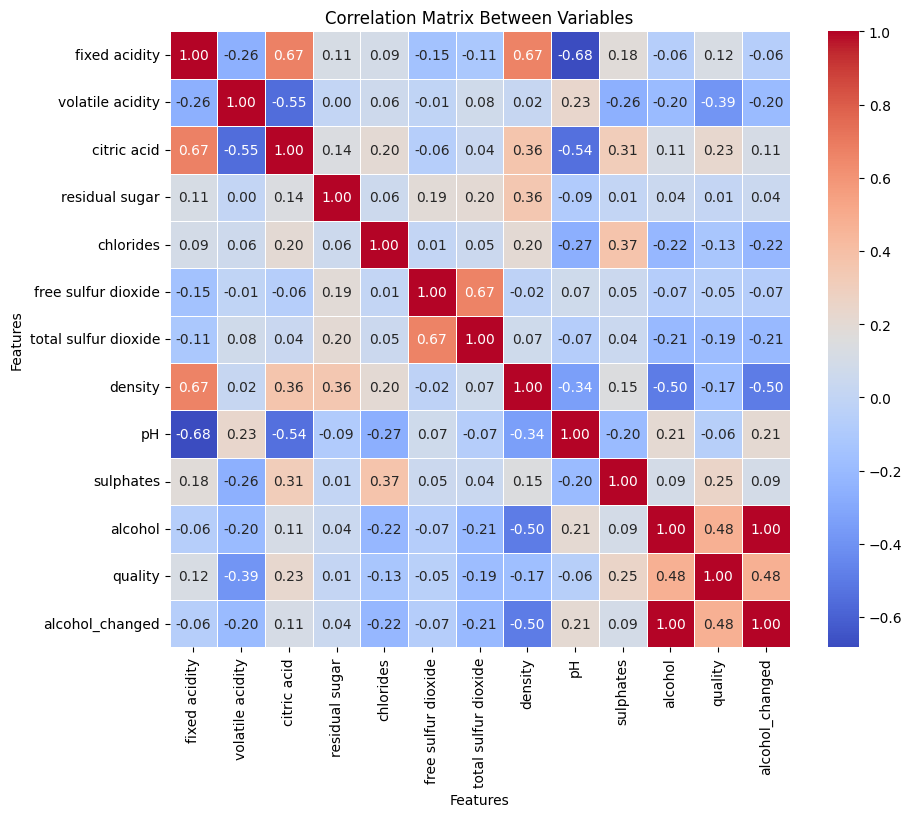

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.drop('quality_label', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Between Variables")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

# Kết thúc